In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.shape

(1599, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(240)

In [11]:
df = df.drop_duplicates()
df.shape

(1359, 12)

In [12]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

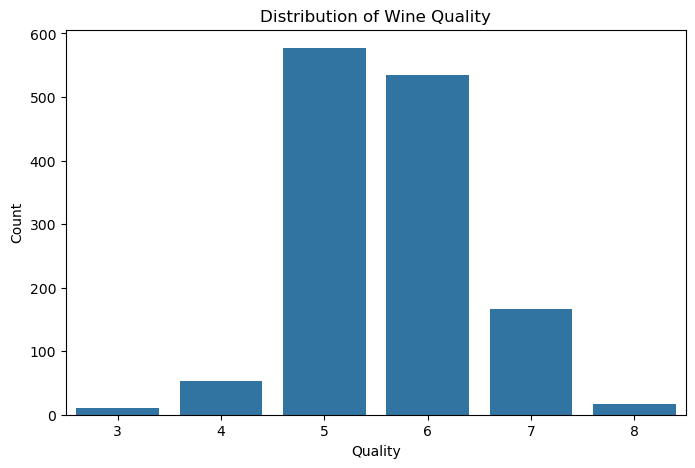

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

Observation

Most of the wines in the dataset have quality ratings of **5** and **6**, indicating that the majority of wine samples are of average quality. Only a small number of wines have quality ratings of **3, 4, and 8**. This shows that the dataset is imbalanced because most of the observations belong to quality levels **5** and **6**, while the other quality categories contain comparatively fewer samples.

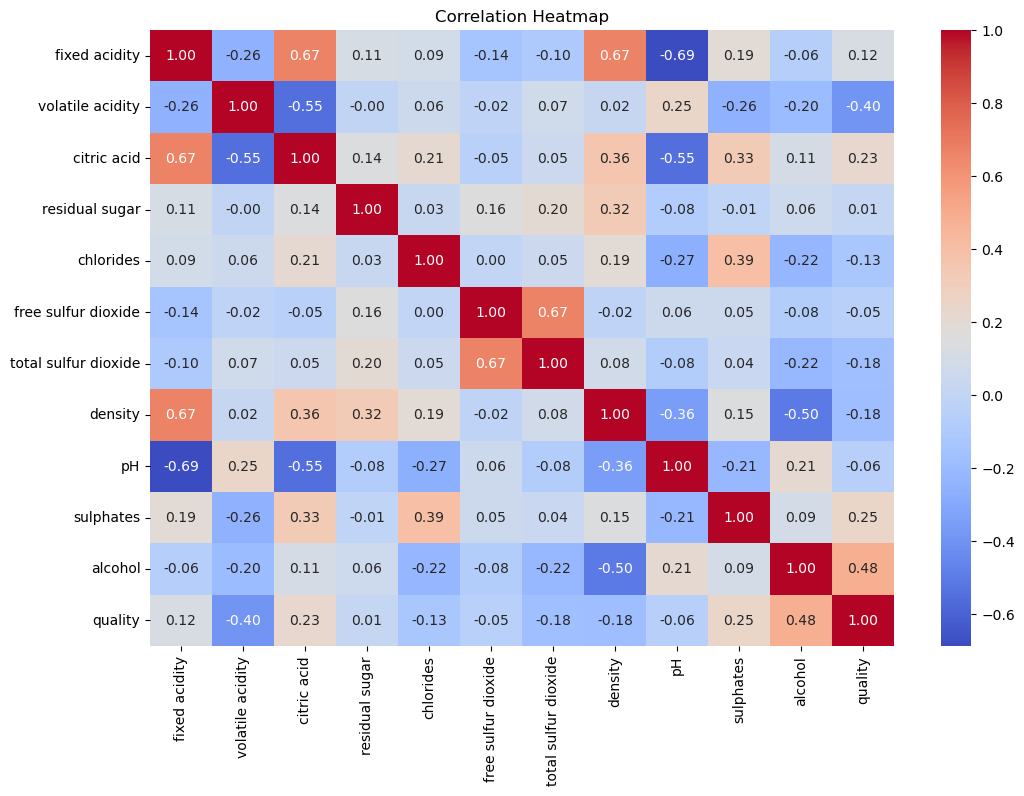

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Observation

The correlation heatmap shows the relationship between different wine attributes. Alcohol has the strongest positive correlation with quality, indicating that wines with higher alcohol content tend to have better quality ratings. Volatile acidity has a negative correlation with quality, suggesting that higher volatile acidity is associated with lower wine quality. Most other features have weak to moderate correlations, indicating that wine quality is influenced by a combination of multiple factors rather than a single feature.

In [15]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1359, 11)
Target Shape: (1359,)


## Observation

The dataset was divided into independent features (X) and the target variable (y). The independent features contain all the chemical properties of wine, while the target variable represents the wine quality rating. This separation is necessary before training a machine learning model.

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1087, 11)
Testing Data: (272, 11)


## Observation

The dataset was split into training and testing sets using an 80:20 ratio. The training dataset is used to train the machine learning model, while the testing dataset is used to evaluate its performance on unseen data.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


Observation

Feature scaling was performed using the StandardScaler technique. This process standardizes the feature values so that each feature has a mean of 0 and a standard deviation of 1. Scaling improves the performance of many machine learning algorithms by ensuring that all features contribute equally during model training.

In [18]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [19]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6507352941176471


Observation

The Random Forest model was evaluated using the testing dataset. The accuracy score represents the percentage of correctly predicted wine quality labels. A higher accuracy indicates better model performance on unseen data.

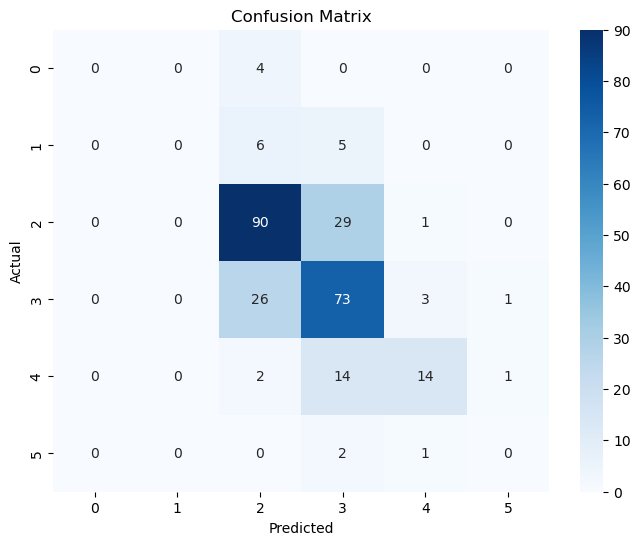

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 Observation

The confusion matrix compares the actual and predicted wine quality labels. Most of the correct predictions are concentrated along the diagonal, indicating that the Random Forest model correctly classified many wine samples. However, some misclassifications are present in the off-diagonal cells, especially between neighboring quality classes. This suggests that the model performs reasonably well but still has difficulty distinguishing wines with similar quality ratings.

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.70      0.75      0.73       120
           6       0.59      0.71      0.65       103
           7       0.74      0.45      0.56        31
           8       0.00      0.00      0.00         3

    accuracy                           0.65       272
   macro avg       0.34      0.32      0.32       272
weighted avg       0.62      0.65      0.63       272



Observation

The classification report shows that the Random Forest model achieved an overall accuracy of approximately 65%. The model performed well for the majority classes, particularly quality levels 5 and 6, which have higher precision and recall values. However, the performance for quality levels 3, 4, and 8 is poor because these classes contain very few samples, making the dataset imbalanced.

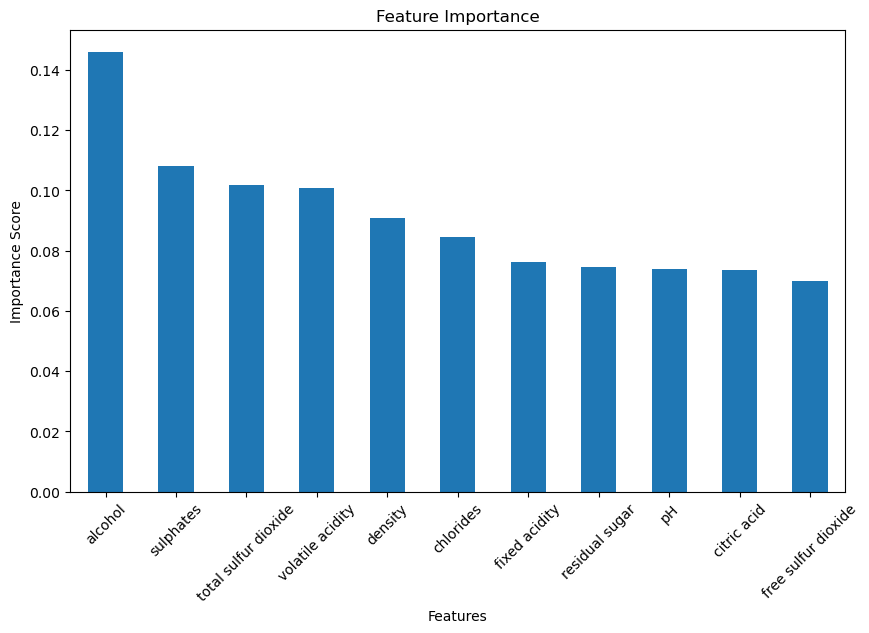

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
feature_importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

Observation

The Feature Importance graph shows the contribution of each feature in predicting wine quality. Alcohol has the highest importance, indicating that it is the most influential feature for prediction. Sulphates, total sulfur dioxide, volatile acidity, and density also contribute significantly. Features with lower importance have less impact on the model's predictions.

In [23]:
import joblib
joblib.dump(model, "../models/wine_quality_model.pkl")
print("Model saved successfully!")

Model saved successfully!
